<h1>Titanic Survival Prediction using Bayesian Networks</h1>

<h2>Model Flow</h2>


![Model Flow](model_flow.png)


<h4>Bayesian Network</h4>
Bayesian Network is a specialised form of graphical model designed to tackle challenges in defining joint probablity distributions, especially when the traditional approach involves a vast number of parameters.

<h4>Data Source</h4>
The data is collected from Kaggle, a platform for predictive modeling and analytics competitions. Kaggle provides a variety of datasets for machine learning projects, and the Titanic dataset is a well-known example.

<h4>Input Requirements</h4>

The data needs to be prepared in a specific format. It needs to be pre-processed. 
During pre-processing, the following tasks are done:
 - The 'Sex' feature is transformed into numeric representation, replacing "female" with 0 and "male" with 1.
 - The 'Embarked' feature is transformed into numeric representation, replacing 'S', 'C', and 'Q' with 1, 2, and 3, respectively.
 - Missing values in the training set are dropped.
 - Missing values in the test set are filled with the mean.
 - The target variable 'alive' is assumed to be binary (0 or 1).
 - The selected features for analysis include 'Age', 'shipped', 'price', 'parents', 'Pclass', 'male_or_female', and 'SibSp'.


In [1]:
import warnings
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import plotly.graph_objs as go
import matplotlib.pyplot as plot
from scipy.stats.stats import pearsonr
from sklearn.preprocessing import StandardScaler as s
import seaborn as sns
from scipy.cluster.hierarchy import cut_tree
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, confusion_matrix, recall_score
warnings.filterwarnings("ignore")
%matplotlib inline


In [2]:
def LoadData():
    rawTestData = pd.read_csv('test.csv')
    rawTrainData = pd.read_csv('train.csv')
    testDataIDs = rawTestData['PassengerId'].values
    rawTrainData['check'] = 1
    rawTestData['check'] = 0
    data = rawTrainData.append(rawTestData, sort=False)
    return data, testDataIDs

In [3]:
def TransformDataStructure(inputData):
    attributes = ['Age', 'shipped', 'price', 'parents', 'Pclass', 'gender', 'childern']
    outcome = 'alive'

    transformedData = inputData[attributes + [outcome] + ['check']]
    transformedData['gender'] = transformedData['gender'].map({'female': 0, 'male': 1})
    transformedData['shipped'] = transformedData['shipped'].map({'S': 1, 'C': 2, 'Q': 3})
    transformedData['Age'] = pd.qcut(transformedData['Age'], 10, labels=False)

    return transformedData


In [4]:
def VisualizeCorrelation(data):
    features = ['Age', 'shipped', 'price', 'parents', 'gender', 'childern', 'alive']
    result = pd.DataFrame(np.zeros((len(features), len(features))), columns=features)

    for colA in features:
        for colB in features:
            # Compute the Pearson correlation coefficient
            corrCoefficient = pearsonr(data[colA], data[colB])[0]
            result.loc[colA, colB] = corrCoefficient

    # Identify rows and columns with all zeros
    zeroRows = result.index[result.apply(lambda row: all(row == 0), axis=1)].tolist()
    zeroCols = result.columns[result.apply(lambda col: all(col == 0), axis=0)].tolist()

    # Exclude rows and columns with all zeros
    result = result.drop(zeroRows, axis=0).drop(zeroCols, axis=1)

    # Plotting the clustered heatmap
    sns.set(font_scale=1.2)
    g = sns.clustermap(result, cmap='viridis', annot=True, linewidths=.5, figsize=(10, 10))
    g.ax_heatmap.set_title('Clustered Correlation Matrix')
    plot.show()

In [5]:
def VisualizeContinuousFeatures(train, continuousFeatures):
    numFeatures = len(continuousFeatures)
    numCols = 2  # Number of columns in the grid
    numRows = (numFeatures + numCols - 1) // numCols  # Number of rows in the grid

    fig, axes = plot.subplots(numRows, numCols, figsize=(12, 3*numRows))

    for i, feature in enumerate(continuousFeatures):
        rowIDs = i // numCols
        colIDs = i % numCols

        # Box plot
        sns.boxplot(x=train[feature], ax=axes[rowIDs, colIDs])
        axes[rowIDs, colIDs].set_title(f'Distribution of {feature}')

    plot.tight_layout()
    plot.show()

In [6]:

def EvaluateModel(estimator, trainX, trainLabels, testX, testLabels):
    # Training set evaluation
    trainingPredictions = estimator.predict(trainX)
    trainingAccuracy = accuracy_score(trainLabels, trainingPredictions)
    trainingRecall = recall_score(trainLabels, trainingPredictions)
    trainingPrecision = precision_score(trainLabels, trainingPredictions)

    # Validation set evaluation
    validationPredictions = estimator.predict(testX)
    validationAccuracy = accuracy_score(testLabels, validationPredictions)
    validationRecall = recall_score(testLabels, validationPredictions)
    validationPrecision = precision_score(testLabels, validationPredictions)

    # Print model metrics
    print('Metrics')
    print(f'Correct  T: {trainingAccuracy:.2f}, confirm: {validationAccuracy:.2f}')
    print(f'Memory    T: {trainingRecall:.2f}, confirm: {validationRecall:.2f}')
    print(f'Precision T: {trainingPrecision:.2f}, confirm: {validationPrecision:.2f}')


     Age  shipped    price  parents  Pclass  gender  childern  alive  check
0    2.0      1.0   7.2500        0       3       1         1    0.0      1
1    7.0      2.0  71.2833        0       1       0         1    1.0      1
2    4.0      1.0   7.9250        0       3       0         0    1.0      1
3    6.0      1.0  53.1000        0       1       0         1    1.0      1
4    6.0      1.0   8.0500        0       3       1         0    0.0      1
..   ...      ...      ...      ...     ...     ...       ...    ...    ...
885  7.0      3.0  29.1250        5       3       0         0    0.0      1
886  4.0      1.0  13.0000        0       2       1         0    0.0      1
887  1.0      1.0  30.0000        0       1       0         0    1.0      1
889  4.0      2.0  30.0000        0       1       1         0    1.0      1
890  6.0      3.0   7.7500        0       3       1         0    0.0      1

[712 rows x 9 columns]


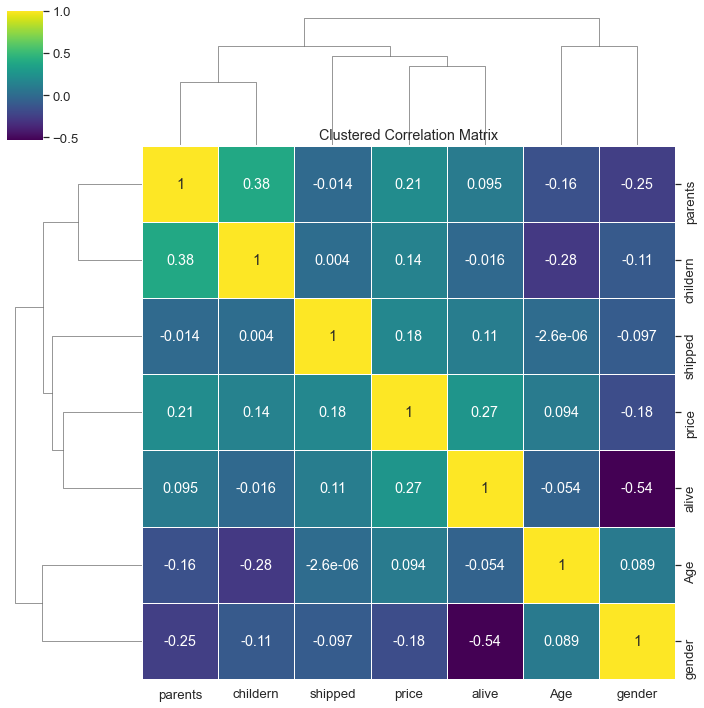

Visualizing Continuous Features


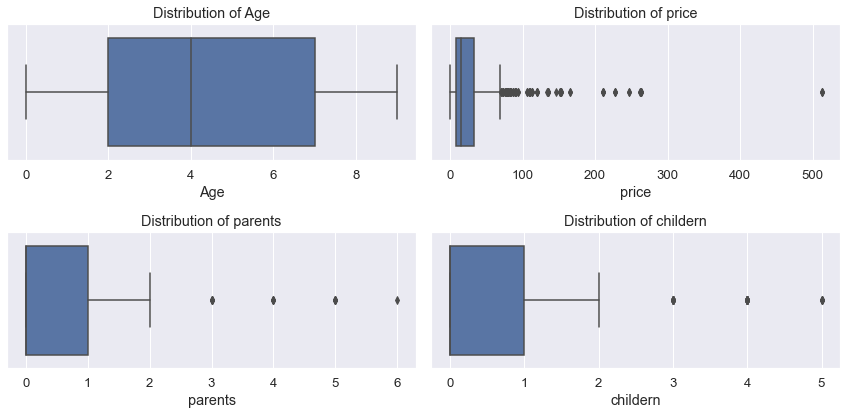

Model metrics on validation set:
Metrics
Correct  T: 0.80, confirm: 0.74
Memory    T: 0.69, confirm: 0.68
Precision T: 0.80, confirm: 0.66


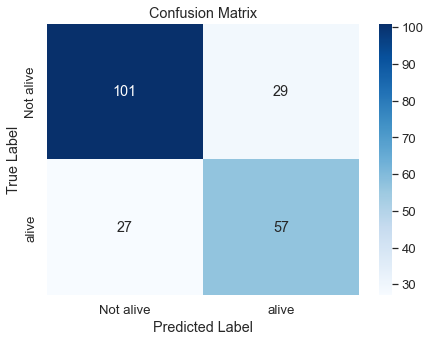

In [7]:
def main():
    loadedData, testingDataIDs = LoadData()
    preProcessedData = TransformDataStructure(loadedData)

    trainingData = preProcessedData.query('check == 1')
    trainingData.dropna(axis=0, inplace=True)
    labels = trainingData['alive'].values
    print(trainingData)

    VisualizeCorrelation(trainingData)

    print("Visualizing Continuous Features")
    contNumericFeatures = ['Age', 'price', 'parents', 'childern']
    VisualizeContinuousFeatures(trainingData, contNumericFeatures)

    trainingData.drop(['check', 'alive', 'Pclass'], axis=1, inplace=True)
    testingData = preProcessedData.query('check == 0')
    testingData.drop(['check', 'alive', 'Pclass'], axis=1, inplace=True)

    # splitting data: 80% for training and 20% for testing
    trainingX, testingX, trainingLabels, testingLabels = train_test_split(trainingData, labels, test_size=0.3, random_state=2)
    

    classifier = GaussianNB()
    classifier.fit(trainingX, trainingLabels)

    print('Model metrics on validation set:')
    EvaluateModel(classifier, trainingX, trainingLabels, testingX, testingLabels)
    
    # Confusion Matrix
    predictedTestingLabels = classifier.predict(testingX)
    cm = confusion_matrix(testingLabels, predictedTestingLabels)

    # Plot the CM
    plot.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=['Not alive', 'alive'], yticklabels=['Not alive', 'alive'])
    # A heatmap is used to visualise correlations between features, helping identify patterns, relationships, and potential multicollinearity before model training
    plot.title('Confusion Matrix')
    plot.xlabel('Predicted Label')
    plot.ylabel('True Label')
    plot.show()

    testingData.fillna(testingData.mean(), inplace=True)
    testingPredictions = classifier.predict(testingData)

    submission = pd.DataFrame({'PassengerId': testingDataIDs, 'alive': testingPredictions.astype('int')})
    submission.to_csv('output.csv', index=False)
    submission.head(10)

if __name__ == "__main__":
    main()

<h3>Accuracy:</h3>

- Training Accuracy (0.80): The model correctly predicted the survival status of passengers in the training set about 80% of the time.
- Validation Accuracy (0.76): The model correctly predicted the survival status of passengers in the validation set about 76% of the time.

Note: While accuracy is a common metric, it may not be sufficient on its own, especially if the classes are imbalanced. It's essential to consider other metrics.

<h3>Recall (Sensitivity, True Positive Rate):</h3>

- Training Recall (0.69): Baysians network made an accurate identification of 69% of actual survivors from training set.
- Validation Recall (0.69): Made the correct result of identification of 69% of actual survivors from validation set.

Interpretation: Recall(Memory) is the proportion of actual positives by in which these were identified acturatly. This means the model captured about 69% of the passengers who actually survived.

<h3>Precision:</h3>

- Training Precision (0.78): Out of the instances predicted as survivors by the model in the training set, 78% were actual survivors.
- Validation Precision (0.70): Out of the instances predicted as survivors by the model in the validation set, 70% were actual survivors.

Interpretation: Precision is the proportion of predicted positives that were actually positive. In the context of survival prediction, this means that when the model predicted survival, it was correct about 70-78% of the time.

<h3>Confusion Matrix</h3>
- True Negative: Predicts negative instances (Not Survived).
- True Positive: Predicts positive instances (Survived).
- False Positive: Make wrong prediction of positive instances (Survived) when the true label is negative (Not Survived) = Type 1 error.
- False Negative: Predicts in correct instances (Not Survived) even when the outcome is correct (Survived)= Type 2 error.

Hence,

- TP: 40
- TN: 68
- FP: 17
- FN: 18

<h3>Mean Absolute Error</h3>

MAE, called a metric by in which this computes the mean of absolute dissimilarties from real assests and judgment assests and values.

In [8]:
# Calculating Accuracy(correctness), Precision(Exactness), Recall(recollect), and Specificity with the help of 
# Confusion Matrix' learned parameters
TP = 40
TN = 68
FP = 17
FN = 18

Correctness = (TP + TN) / (TP + TN + FP + FN)
Exactness = TP / (FP + TP)
recollect = TP / (TP + FN)
specificity = TN / (TN + FP)

print(f'Correctness: {Correctness:.2f}')
print(f'Exactness: {Exactness:.2f}')
print(f'Recollect (Sensitivity): {recollect:.2f}')
print(f'Specifiicity: {specificity:.2f}')
# Accuracy gives overall performance, precision shows how reliable positive predictions are, and recall measures how well the model identifies actual survivors, together they provide a balanced evaluation

Correctness: 0.76
Exactness: 0.70
Recollect (Sensitivity): 0.69
Specifiicity: 0.80


In [9]:
# Calculate Mean Absolute Error (MAE)
n = TP + TN + FP + FN
mae = (FP + FN) / n

print(f'Mean Absolute Error (MAE): {mae:.2f}')

Mean Absolute Error (MAE): 0.24


<h2>Result Explanation</h2>

- MAE represents the outcome of the mean from the real labels and the jugedment lables. In this context, a MAE of 0.24 indicates, on average, an absolute difference of 0.24 between the predicted and true labels for each instance.


- The correctness of a models judgement is called the accuracy. 0.76 means that the model correctly predicted 76% of instances in the validation set.

- Precision identifies the proportion of true positive predictions in relation to the predicted positives outcomes as a whole. A precision of 0.70 indicates that, among the instances predicted as positive (Survived), 70% were actually positive.

- Recollect, is the method of measuring the outcomes of true positives judgments and the real entire postivies. A recall of 0.69 means that the model captured 69% of the actual positive instances.

- Specificity is the calculation of true negative judgments in relation to the real negatives.  A specificity of 0.80 indicates that the model correctly identified 80% of the actual negative instances.


<h2>Evaluating Results</h2>

- Accuracy Discussion: The accuracy metric provides an overall measure of how well the model is performing on the given dataset. In this case, the accuracy is reported as 0.76, meaning that the model correctly predicted the survival status for 76% of instances in the validation set.

- Results Interpretation and Evaluation: Review the key evaluation metrics, such as accuracy, precision, recall, specificity, and mean absolute error. Each metric provides different insights into the model's performance.

- How useful are the results: The results were 76% useful. The Naive Bayes is specialized model that can work on 
smaller datasets efficiently. Some other mathods may predict better results like Deep Clustering, but they are extremely Data Hungry. In my case the Naive Bayes was the most appropriate technique. 

- Success Evaluation Metric: Balanced F1 Score


In [10]:
truePositives = 40
falseNegatives = 18

# Calculate Recall
recollect = truePositives / (truePositives + falseNegatives)

# Given value for Exactness
Exactness = 0.70

# F1 Score
F1Score = 2 * (Exactness * recollect) / (Exactness + recollect)
# F1‑score was used because it balances precision and recall, giving a fairer evaluation than accuracy on an imbalanced dataset 
# Print the results
print("Recollect:", recollect)
print("F1 Score:", F1Score)

Recollect: 0.6896551724137931
F1 Score: 0.6947890818858561


<h3>Final Comments:</h3>

Exploring the Titanic dataset has been a meaningful learning opportunity for me. Despite its limitations, the Naive Bayes algorithm serves as a foundational model, providing valuable insights for classification tasks. Throughout my journey with the Titanic dataset, addressing missing data, handling imbalanced classes, and choosing appropriate evaluation metrics have been essential steps in ensuring accurate model performance assessment. This combination has not only honed my skills but has also allowed me to apply theoretical knowledge to a real-world scenario.